In [14]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from qopt_funcs import *
from network_funcs import *
import pandas as pd
import random

In [2]:
# These are the standard parameters for SPDCs and SNSPCs
PARAMS = {
    'p_det': 0.95,          # Detector efficiency
    'alpha': 0.18,          # Fiber loss (dB/km)
    'q_0': 0.01,            # Baseline QBER (Check)
    'nu': 10**9,            # Repetition rate (1 GHz) !! Check
    'R_dark': 100,          # Dark count rate (Hz)
    'delta_det': 100.E-12,  # Time gate duration (s) !! Check
    'p_pair': 0.05,         # Pair generation probability
    'eta_c': 0.8,           # Source to fiber coupling

}

In [4]:
N=1000
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233
A, dist, coords = S2_graph_definite_N(N, beta, mu, D=2, sample_from_file=False, return_coords=True)
dist = 10*dist # To simulate city size (max distance ~31 km)
print(coords)

[[-0.22566639  0.96960494 -0.09455654]
 [ 0.43154619 -0.42576077  0.79529595]
 [ 0.14915492  0.45597213 -0.87740653]
 ...
 [-0.82772004 -0.49546109  0.2634347 ]
 [ 0.36169781  0.67998343 -0.63780658]
 [ 0.06838253 -0.86936017 -0.48942489]]


In [5]:
def build_prob_matrix(A, dist, architecture='node'):
    # Check
    if architecture == 'node':
        dist_A=np.zeros(np.shape(dist))
        dist_B=dist
    elif architecture == 'midpoint':
        dist_A=dist/2
        dist_B=dist/2
    else:
        raise ValueError('architecture must be node or midpoint')
    eta_A_mtx = PARAMS['eta_c'] * PARAMS['p_det'] * 10**(-PARAMS['alpha'] * dist_A / 10)*A # Multiply by Adjacency matrix to keep only existing edges
    eta_B_mtx = PARAMS['eta_c'] * PARAMS['p_det'] * 10**(-PARAMS['alpha'] * dist_B / 10)*A
    P_ent_matrix = PARAMS['p_pair'] * eta_A_mtx * eta_B_mtx
    return P_ent_matrix, eta_A_mtx, eta_B_mtx

Probs_mtx, eta_A_mtx, eta_B_mtx = build_prob_matrix(A, dist, architecture='node')
print(Probs_mtx>0)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [6]:
def optimal_quantum_repeater_path(Probs_mtx, source, target=None,  P_BSM=0.5): # structured like nx.single_source_dijkstra
    W = np.zeros(np.shape(Probs_mtx))
    none_zero_edges = Probs_mtx>0
    W[none_zero_edges] = -np.log2(Probs_mtx[none_zero_edges]) - np.log2(P_BSM)
    G = nx.from_numpy_array(W)
    weights, paths = nx.single_source_dijkstra(G, source, target=target, weight='weight')
    #weights = np.exp(weights + np.log2(P_BSM))   # to avoid overcounting the Bell state success probability
    return weights, paths

weights, paths = optimal_quantum_repeater_path(Probs_mtx, 0)
path = paths[250]
path

[0, 474, 250]

In [7]:
def calculate_expected_sequential_time(path, Probs_mtx, P_BSM=0.5):
    a = path[0] # First Node
    b = path[1] # Second Node
    T=1/Probs_mtx[a, b]
    for i in range(2,len(path)):
        a = path[i-1]
        b = path[i]
        T_i=1/Probs_mtx[a, b]
        T=(T+T_i)/P_BSM
    return T

total_time = calculate_expected_sequential_time(path, Probs_mtx)
print(total_time)

146.78534978642296


In [8]:
def calculate_distances(path, dist):
    relevant_dists = []
    for i in range(1,len(path)):
        a = path[i-1]
        b = path[i]
        relevant_dists.append(dist[a,b])
    return relevant_dists
print(calculate_distances(path, dist))

[np.float64(2.494227769774553), np.float64(0.256099325556168)]


## Post processing functions

In [9]:
def entanglement_generation_rate(total_time):
    return 0.5*PARAMS['nu']/total_time

def QBER(eta_A_mtx, eta_B_mtx, path):
    p_darkcount = PARAMS['R_dark']*PARAMS['delta_det']
    W=1
    for i in range(1, len(path)):
        a = path[i-1]
        b = path[i]
        eta_A = eta_A_mtx[a,b]
        eta_B = eta_B_mtx[a,b]
        p_acc = PARAMS['p_pair']*eta_A*(1-eta_B)*p_darkcount+PARAMS['p_pair']*eta_B*(1-eta_A)*p_darkcount+p_darkcount**2
        p_det = PARAMS['p_pair']*eta_A*eta_B
        Q_i = (p_det*(PARAMS['q_0']+PARAMS['p_pair']/2)+0.5*p_acc)/(p_det + p_acc)
        W_i = 1-2*Q_i
        W = W*W_i
    return (1-W)/2
R_ent = entanglement_generation_rate(total_time)
Q = QBER(eta_A_mtx, eta_B_mtx, path)
print(Q)

0.06755000614295792


In [10]:
def secret_key_rate_BBM92(R_ent, Q):
    H = binary_entropy(Q)
    return R_ent*(1-2*H)
secret_key_rate_BBM92(R_ent*0.5, Q)

np.float64(488081.703597974)

In [126]:
paths.items()

dict_items([(0, [0]), (90, [0, 90]), (306, [0, 90, 306]), (737, [0, 90, 306, 737]), (62, [0, 90, 306, 62]), (665, [0, 90, 306, 665]), (319, [0, 90, 306, 319]), (715, [0, 90, 306, 715]), (175, [0, 90, 306, 175]), (974, [0, 90, 306, 737, 974]), (483, [0, 90, 306, 715, 483]), (490, [0, 90, 306, 715, 490]), (35, [0, 90, 306, 715, 35]), (274, [0, 90, 306, 715, 274]), (922, [0, 90, 306, 715, 922]), (74, [0, 90, 306, 715, 74]), (310, [0, 90, 306, 715, 310]), (438, [0, 90, 306, 715, 438]), (505, [0, 90, 306, 715, 505]), (669, [0, 90, 306, 715, 669]), (583, [0, 90, 306, 715, 583]), (675, [0, 90, 306, 715, 675]), (166, [0, 90, 306, 715, 166]), (858, [0, 90, 306, 715, 858]), (265, [0, 90, 306, 715, 265]), (79, [0, 90, 306, 715, 79]), (81, [0, 90, 306, 715, 81]), (194, [0, 90, 306, 715, 194]), (135, [0, 90, 306, 715, 135]), (38, [0, 90, 306, 715, 38]), (497, [0, 90, 306, 715, 497]), (720, [0, 90, 306, 715, 720]), (963, [0, 90, 306, 715, 963]), (908, [0, 90, 306, 715, 908]), (161, [0, 90, 306, 175,

Let's see which routes work, in a graph

In [12]:
def multiple_paths(paths, Probs_mtx, eta_A_mtx, eta_B_mtx, P_BSM=0.5):
    records = []
    paths.pop(next(iter(paths)))  # removes the first key
    for i, path in paths.items():
        total_time = calculate_expected_sequential_time(path, Probs_mtx, P_BSM)
        Q = QBER(eta_A_mtx, eta_B_mtx, path)
        R_ent = entanglement_generation_rate(total_time)
        SKR = secret_key_rate_BBM92(R_ent, Q)

        records.append({
            'total_time': total_time,
            'Q': Q,
            'SKR': SKR,
            'path': path

        })

    df = pd.DataFrame(records, index=paths.keys())
    return df

df = multiple_paths(paths, Probs_mtx, eta_A_mtx, eta_B_mtx, P_BSM=0.5)
display(df)

,total_time,Q,SKR,path
250,146.785350,0.067550,976163.407196,"[0, 474, 250]"
924,151.331709,0.067550,946837.158447,"[0, 474, 924]"
189,152.867887,0.067550,937322.340417,"[0, 474, 189]"
798,178.425577,0.067550,803060.188094,"[0, 474, 798]"
655,377.194758,0.097822,100606.768694,"[0, 474, 189, 655]"
...,...,...,...,...
56,9718.772180,0.199150,-22659.654884,"[0, 474, 189, 907, 814, 176, 449, 56]"
931,14860.868294,0.220209,-17532.565929,"[0, 474, 189, 143, 226, 441, 203, 13, 931]"
976,14786.997240,0.220209,-17620.153206,"[0, 474, 189, 655, 811, 30, 145, 517, 976]"
864,29792.534028,0.239794,-9891.684069,"[0, 474, 189, 143, 226, 441, 203, 13, 931, 864]"


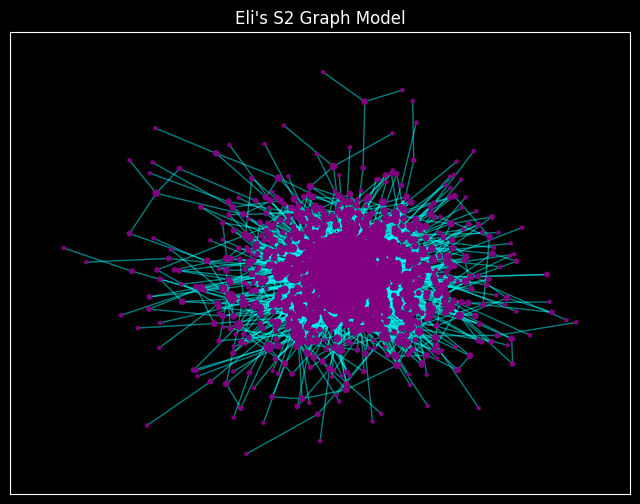

In [104]:
G_s2 = nx.from_numpy_array(A)  # Convert adjacency matrix to graph
degrees_s2 = dict(G_s2.degree())
node_size_s2 = [v * 5 for v in degrees_s2.values()]
pos_s2 = nx.spring_layout(G_s2, k=5.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_s2, pos_s2, node_size=node_size_s2, node_color='purple')
nx.draw_networkx_edges(G_s2, pos_s2, alpha=0.5, edge_color='cyan')
plt.title("Eli's S2 Graph Model")
#plt.savefig("S2_model_sping.pdf")
plt.show()

## Custom graph example

In [15]:
def build_graph(n_hubs, avg_n_branches):
    G = nx.Graph()

    # 1. Build the Backbone
    # Hubs will be assigned IDs from 0 to (n_hubs - 1)
    for i in range(n_hubs - 1):
        dist = random.randint(150, 250) * 0.1  # 15.0 to 25.0 km
        G.add_edge(i, i+1, weight=dist)

    # 2. Build the Branches
    # Keep a running counter for unique leaf IDs so they don't overlap
    next_leaf_id = n_hubs

    for i in range(n_hubs): # Loop through ALL hubs
        # Generate random number of branches (ensure it doesn't go negative)
        n_branches = max(0, random.randint(avg_n_branches - 3, avg_n_branches + 3))

        for _ in range(n_branches):
            dist = random.randint(20, 50) * 0.1  # 2.0 to 5.0 km
            G.add_edge(i, next_leaf_id, weight=dist)
            next_leaf_id += 1 # Increment for the next unique leaf

    # 3. Extract Matrices
    A = nx.to_numpy_array(G, weight=None)          # weight=None guarantees pure 1s and 0s
    dists = nx.to_numpy_array(G, weight='weight')  # Grabs the km values

    return A, dists

In [17]:
A, dists = build_graph(4, 6)